# 01 — Analyse Exploratoire des Données (EDA)

Exploration des **deux** jeux de données du projet Bank Marketing :
- **Partie A** : Dataset Bank (UCI original) — `bank-full.csv`, 45 211 instances, 17 colonnes
- **Partie B** : Dataset Bank Additional (enrichi) — `bank-additional-full.csv`, 41 188 instances, 21 colonnes
- **Partie C** : Analyse comparative

In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.insert(0, '..')

from src.data_loader import load_bank, load_bank_additional, get_dataset_info
from src.eda import (
    summarize, analyze_missing,
    plot_target_distribution, plot_numerical_distributions,
    plot_categorical_distributions, plot_correlation_matrix,
)
from src.utils import set_seed

set_seed(42)
%matplotlib inline

---
# PARTIE A — Dataset Bank (UCI Original)

16 variables + cible, pas d'indicateurs économiques.

In [2]:
df_bank = load_bank(full=True)
get_dataset_info(df_bank, name='Bank Dataset (full)')

  Bank Dataset (full)
Shape: 45,211 rows × 17 columns

Columns (17):
   1. age                   dtype=int64
   2. job                   dtype=str
   3. marital               dtype=str
   4. education             dtype=str
   5. default               dtype=str
   6. balance               dtype=int64
   7. housing               dtype=str
   8. loan                  dtype=str
   9. contact               dtype=str
  10. day                   dtype=int64
  11. month                 dtype=str
  12. duration              dtype=int64
  13. campaign              dtype=int64
  14. pdays                 dtype=int64
  15. previous              dtype=int64
  16. poutcome              dtype=str
  17. y                     dtype=str

Missing values:
  None (note: 'unknown' is used as a category label)

Target distribution:
y
no     39922
yes     5289

First 5 rows:
   age           job  marital  education default  balance housing loan  contact  day month  duration  campaign  pdays  previous poutcome

## A.1 — Statistiques descriptives

In [3]:
summarize(df_bank)

Numerical features summary:
            age    balance       day  duration  campaign     pdays  previous
count  45211.00   45211.00  45211.00  45211.00  45211.00  45211.00  45211.00
mean      40.94    1362.27     15.81    258.16      2.76     40.20      0.58
std       10.62    3044.77      8.32    257.53      3.10    100.13      2.30
min       18.00   -8019.00      1.00      0.00      1.00     -1.00      0.00
25%       33.00      72.00      8.00    103.00      1.00     -1.00      0.00
50%       39.00     448.00     16.00    180.00      2.00     -1.00      0.00
75%       48.00    1428.00     21.00    319.00      3.00     -1.00      0.00
max       95.00  102127.00     31.00   4918.00     63.00    871.00    275.00

Categorical features summary:
  job: 12 unique values
  marital: 3 unique values
  education: 4 unique values
  default: 2 unique values
  housing: 2 unique values
  loan: 2 unique values
  contact: 3 unique values
  month: 12 unique values
  poutcome: 4 unique values
  y: 2 un

## A.2 — Valeurs 'unknown'

In [4]:
unknown_bank = analyze_missing(df_bank)

'unknown' values per column:
  poutcome: 36959 (81.7%)
  contact: 13020 (28.8%)
  education: 1857 (4.1%)
  job: 288 (0.6%)


## A.3 — Distribution de la cible

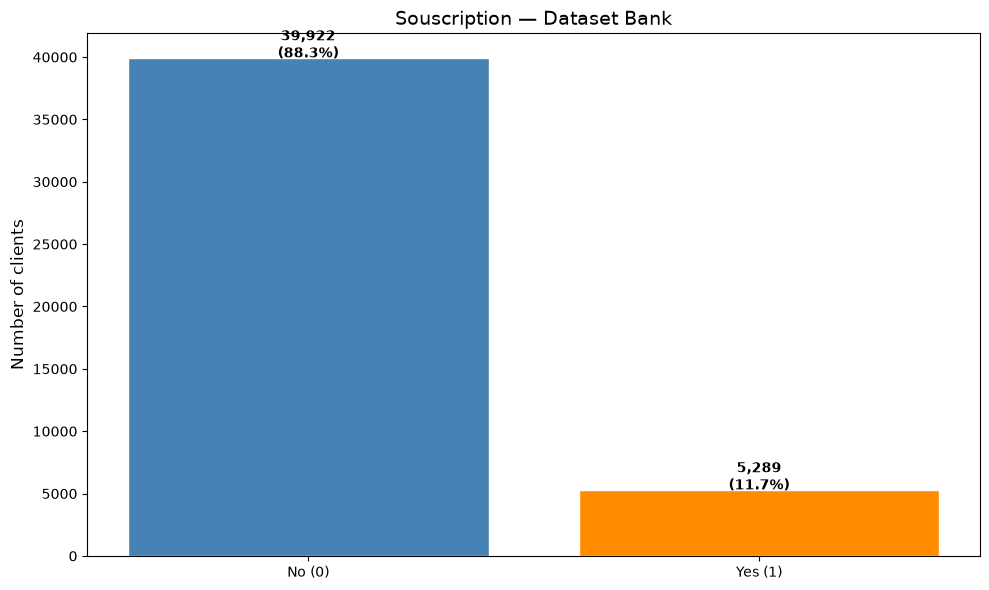

In [5]:
y_bank = df_bank['y'].map({'yes': 1, 'no': 0})
plot_target_distribution(y_bank, title='Souscription — Dataset Bank')

## A.4 — Variables numériques

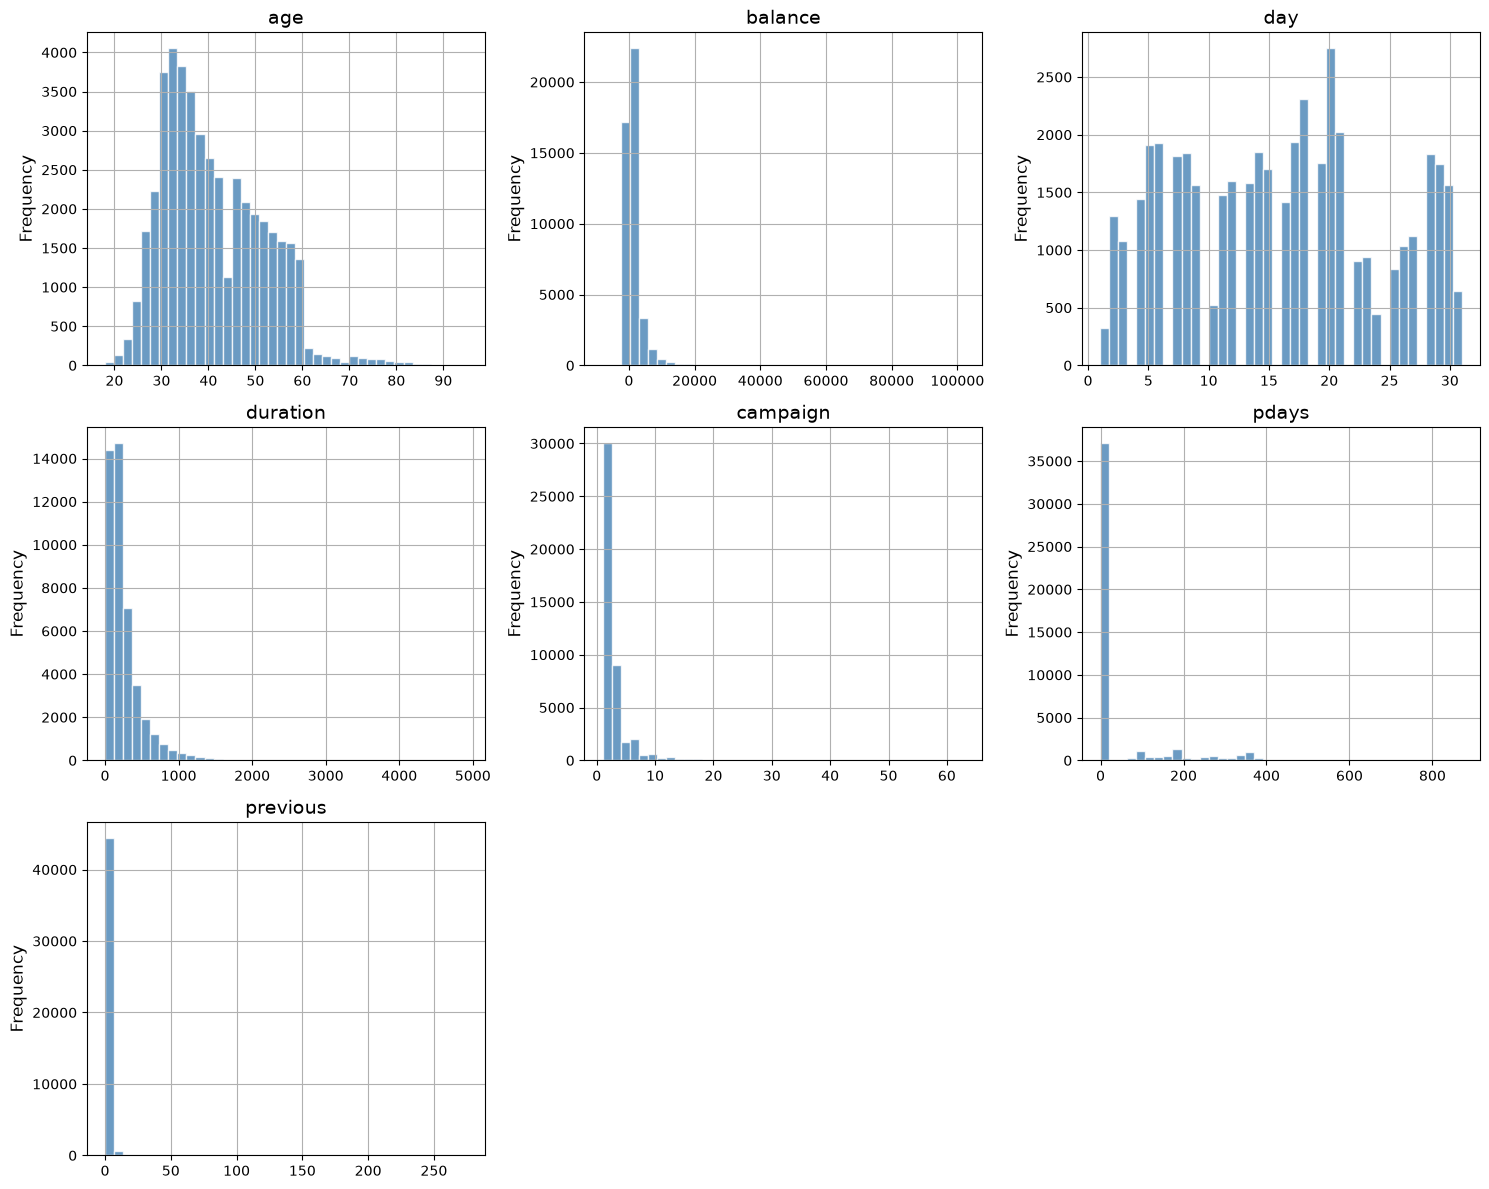

In [6]:
plot_numerical_distributions(df_bank)

## A.5 — Variables catégorielles

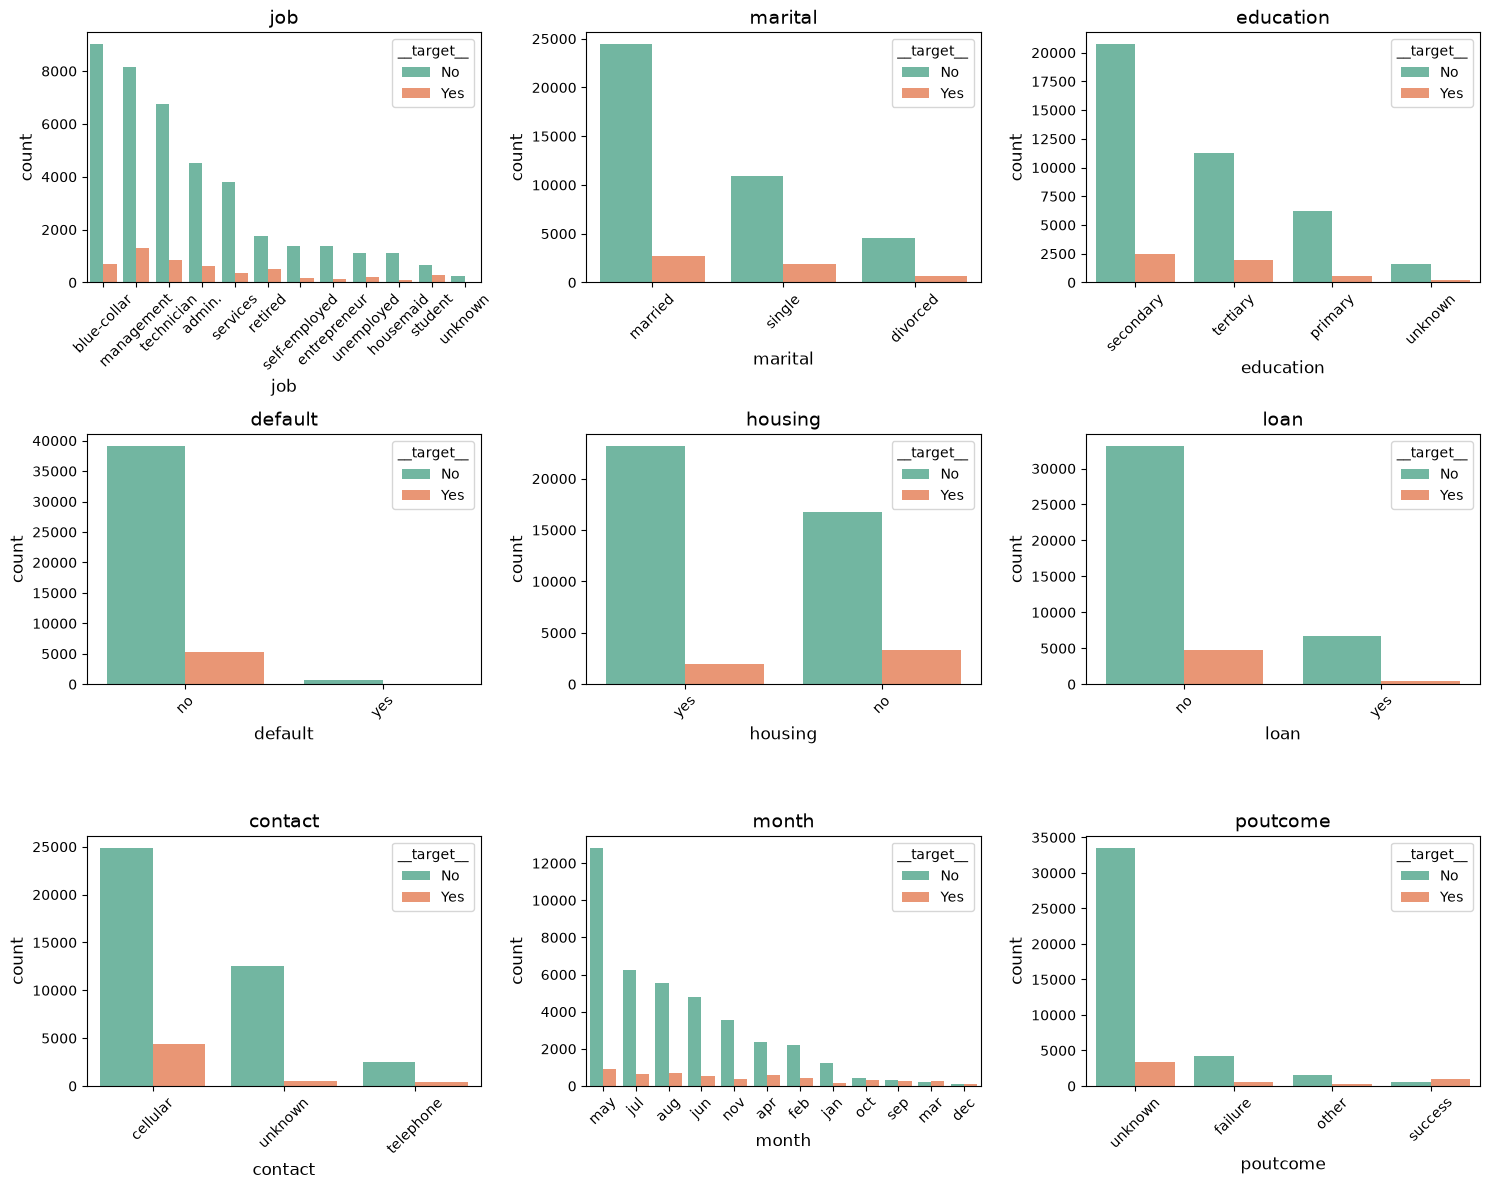

In [7]:
plot_categorical_distributions(df_bank, target=y_bank)

## A.6 — Matrice de corrélation

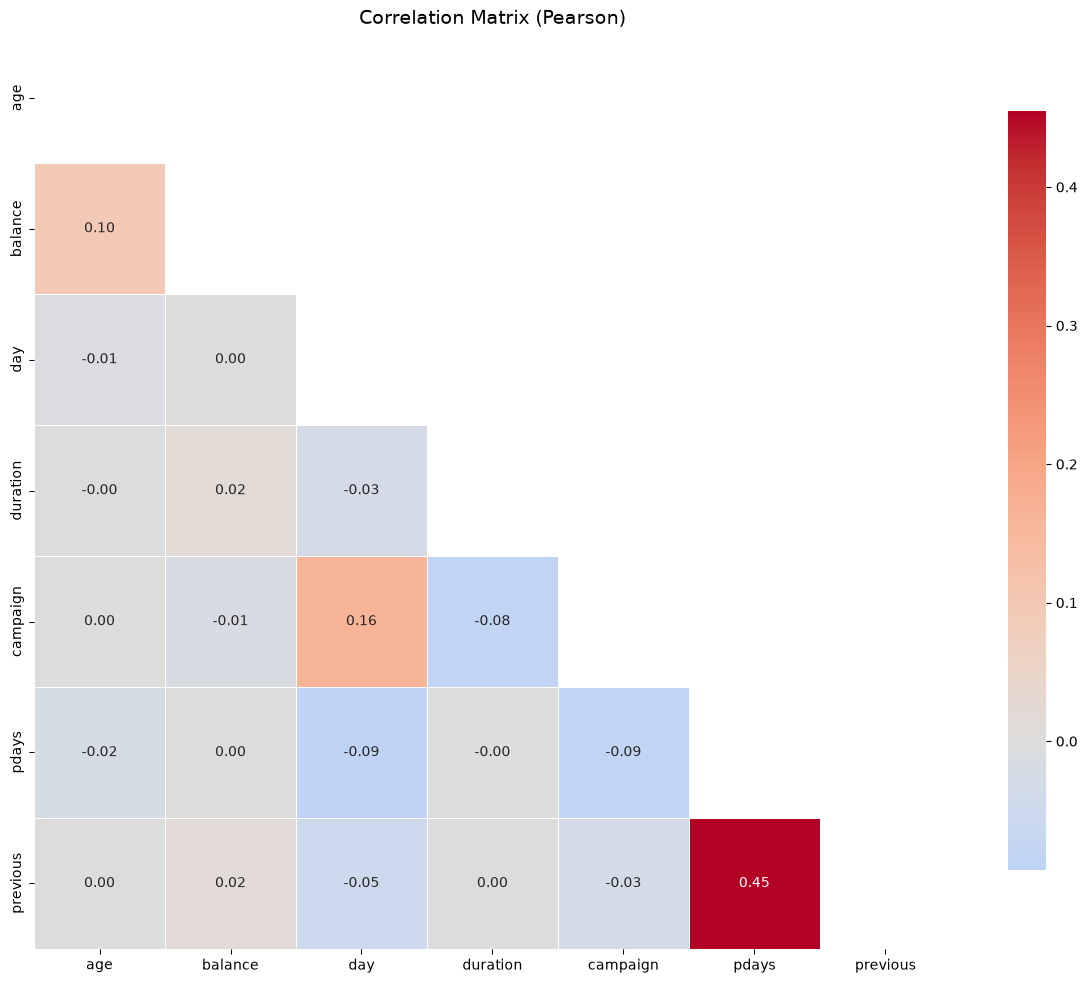

In [8]:
plot_correlation_matrix(df_bank)

## A.7 — Conclusions partie A

- ...

---
# PARTIE B — Dataset Bank Additional (enrichi)

20 variables + cible, inclut 5 indicateurs socio-économiques :
- `emp.var.rate` — taux de variation de l'emploi (trimestriel)
- `cons.price.idx` — indice des prix à la consommation (mensuel)
- `cons.conf.idx` — indice de confiance des consommateurs (mensuel)
- `euribor3m` — taux Euribor 3 mois (quotidien)
- `nr.employed` — nombre d'employés (trimestriel)

In [9]:
df_add = load_bank_additional(full=True)
get_dataset_info(df_add, name='Bank Additional Dataset (full)')

  Bank Additional Dataset (full)
Shape: 41,188 rows × 21 columns

Columns (21):
   1. age                   dtype=int64
   2. job                   dtype=str
   3. marital               dtype=str
   4. education             dtype=str
   5. default               dtype=str
   6. housing               dtype=str
   7. loan                  dtype=str
   8. contact               dtype=str
   9. month                 dtype=str
  10. day_of_week           dtype=str
  11. duration              dtype=int64
  12. campaign              dtype=int64
  13. pdays                 dtype=int64
  14. previous              dtype=int64
  15. poutcome              dtype=str
  16. emp.var.rate          dtype=float64
  17. cons.price.idx        dtype=float64
  18. cons.conf.idx         dtype=float64
  19. euribor3m             dtype=float64
  20. nr.employed           dtype=float64
  21. y                     dtype=str

Missing values:
  None (note: 'unknown' is used as a category label)

Target distribution:


## B.1 — Statistiques descriptives

In [10]:
summarize(df_add)

Numerical features summary:
            age  duration  campaign     pdays  previous  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed
count  41188.00  41188.00  41188.00  41188.00  41188.00      41188.00        41188.00       41188.00   41188.00     41188.00
mean      40.02    258.29      2.57    962.48      0.17          0.08           93.58         -40.50       3.62      5167.04
std       10.42    259.28      2.77    186.91      0.49          1.57            0.58           4.63       1.73        72.25
min       17.00      0.00      1.00      0.00      0.00         -3.40           92.20         -50.80       0.63      4963.60
25%       32.00    102.00      1.00    999.00      0.00         -1.80           93.08         -42.70       1.34      5099.10
50%       38.00    180.00      2.00    999.00      0.00          1.10           93.75         -41.80       4.86      5191.00
75%       47.00    319.00      3.00    999.00      0.00          1.40           93.99         -36

## B.2 — Valeurs 'unknown'

In [11]:
unknown_add = analyze_missing(df_add)

'unknown' values per column:
  default: 8597 (20.9%)
  education: 1731 (4.2%)
  housing: 990 (2.4%)
  loan: 990 (2.4%)
  job: 330 (0.8%)
  marital: 80 (0.2%)


## B.3 — Distribution de la cible

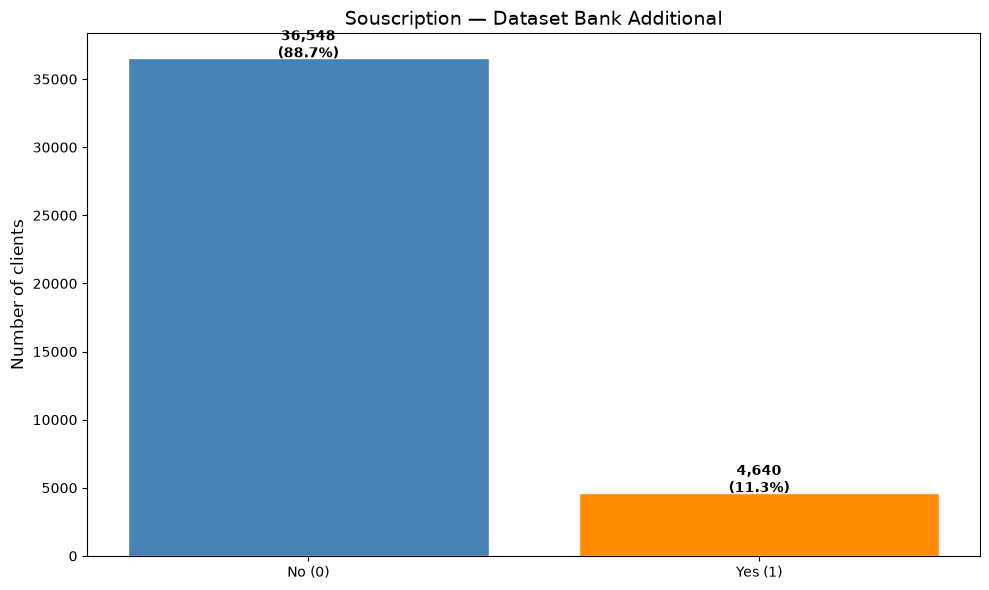

In [12]:
y_add = df_add['y'].map({'yes': 1, 'no': 0})
plot_target_distribution(y_add, title='Souscription — Dataset Bank Additional')

## B.4 — Variables numériques

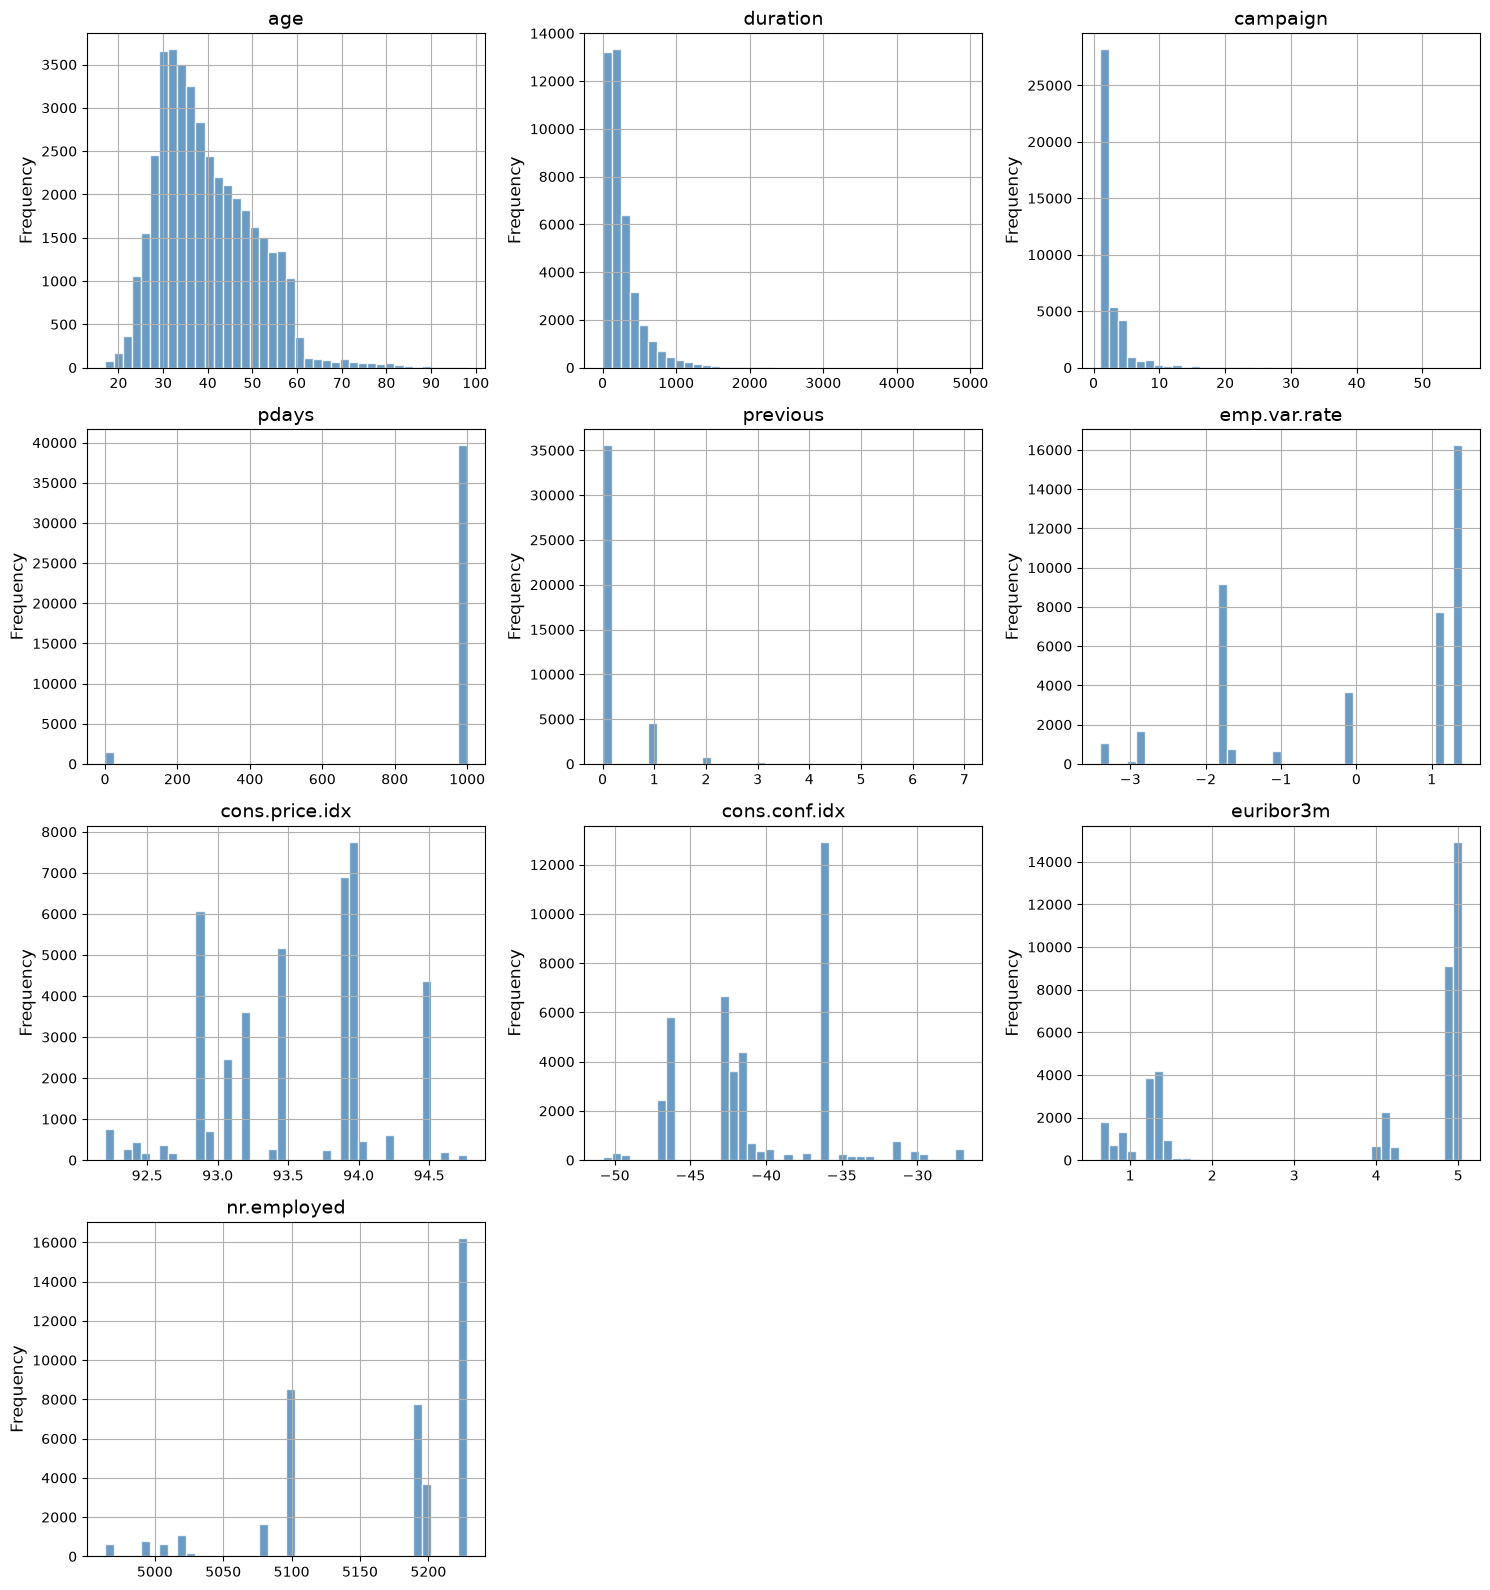

In [13]:
plot_numerical_distributions(df_add)

## B.5 — Focus : indicateurs socio-économiques

In [14]:
econ_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
print(df_add[econ_cols].describe().round(3).to_string())
print(f"\nCorrélations avec la cible :")
for col in econ_cols:
    corr = df_add[col].corr(y_add)
    print(f"  {col}: {corr:.4f}")

       emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed
count     41188.000       41188.000      41188.000  41188.000    41188.000
mean          0.082          93.576        -40.503      3.621     5167.036
std           1.571           0.579          4.628      1.734       72.252
min          -3.400          92.201        -50.800      0.634     4963.600
25%          -1.800          93.075        -42.700      1.344     5099.100
50%           1.100          93.749        -41.800      4.857     5191.000
75%           1.400          93.994        -36.400      4.961     5228.100
max           1.400          94.767        -26.900      5.045     5228.100

Corrélations avec la cible :
  emp.var.rate: -0.2983
  cons.price.idx: -0.1362
  cons.conf.idx: 0.0549
  euribor3m: -0.3078
  nr.employed: -0.3547


In [15]:
# Évolution temporelle des indicateurs (si ordre chronologique préservé)
fig, axes = plt.subplots(len(econ_cols), 1, figsize=(14, 3*len(econ_cols)), sharex=True)
for i, col in enumerate(econ_cols):
    axes[i].plot(df_add[col].values, linewidth=0.5, alpha=0.7)
    axes[i].set_ylabel(col)
    axes[i].grid(alpha=0.3)
axes[-1].set_xlabel('Index (ordre chronologique)')
fig.suptitle('Évolution des indicateurs socio-économiques (mai 2008 — nov 2010)', fontsize=13)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

## B.6 — Variables catégorielles

In [ ]:
plot_categorical_distributions(df_add, target=y_add)

## B.7 — Matrice de corrélation

In [ ]:
plot_correlation_matrix(df_add)

## B.8 — Conclusions partie B

- ...

---
# PARTIE C — Analyse comparative

Comparaison rapide des deux datasets : taille, distribution de la cible, variables communes.

In [ ]:
print(f"{'='*60}")
print(f"  Comparaison Bank vs Bank Additional")
print(f"{'='*60}")
print(f"Instances  — Bank: {len(df_bank):,}  |  Additional: {len(df_add):,}")
print(f"Colonnes   — Bank: {df_bank.shape[1]}  |  Additional: {df_add.shape[1]}")
print(f"\nTaux de souscription (y='yes') :")
print(f"  Bank:       {(df_bank['y'] == 'yes').sum() / len(df_bank) * 100:.2f}%")
print(f"  Additional: {(df_add['y'] == 'yes').sum() / len(df_add) * 100:.2f}%")
print(f"\nVariables communes :")
common = set(df_bank.columns) & set(df_add.columns)
print(f"  {len(common)} colonnes : {sorted(common)}")
print(f"\nVariables specifiques a Bank :")
only_bank = set(df_bank.columns) - set(df_add.columns)
print(f"  {sorted(only_bank)}")
print(f"\nVariables specifiques a Additional :")
only_add = set(df_add.columns) - set(df_bank.columns)
print(f"  {sorted(only_add)}")

## Conclusions générales de l'EDA

- Le jeu de données est **fortement déséquilibré** (~12% de "yes")
- L'attribut `duration` est très corrélé à la cible mais **doit être exclu** des modèles prédictifs réalistes
- Les indicateurs socio-économiques du dataset Additional apportent un **contexte macro** potentiellement informatif
- Les valeurs `unknown` concernent plusieurs colonnes et nécessitent une stratégie de traitement
- ...